# PINN for Parametric Navier–Stokes
**MODEL ORDER REDUCTION AND MACHINE LEARNING – Project A.Y. 2025/2026**  
Francabandiera Riccardo (s345950) · Morandi Simone Domenico (s336974) · Pautasso Elisabetta (s337091)

Solve the parametric NS equations on $\Omega=(0,1)^2$ using a Physics-Informed Neural Network (PINN).  
Parameters: $\mu_0\in[0.1,10]$ (viscosity), $\mu_1\in[1,3]$ (forcing frequency).


## 1 · Imports and device setup

In [7]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats.qmc import LatinHypercube, scale
from scipy.interpolate import griddata
import time, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 2 · Network architecture

In [8]:
class FourierEmbedding(nn.Module):
    """
    Input x (normalized to [-1,1]) through fixed random sinusoids:
        φ(x) = [sin(Bx), cos(Bx)]   →   output dim = 2 * n_freqs
    B is sampled once at init and never updated during training.
    """
    def __init__(self, in_dim, n_freqs=64, sigma=5.0):
        super().__init__()
        B = torch.randn(in_dim, n_freqs) * sigma
        self.register_buffer('B', B)

    def forward(self, x):
        proj = x @ self.B                                        
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

In [9]:
class DNN(nn.Module):
    """4-hidden-layer tanh network preceded by a Fourier embedding."""
    def __init__(self, in_dim=4, n_freqs=64, hidden_dim=64, n_layers=4,
                 out_dim=3, sigma=1.0):
        super().__init__()
        self.embed = FourierEmbedding(in_dim, n_freqs, sigma)
        embed_dim  = 2 * n_freqs

        layers = []
        dims = [embed_dim] + [hidden_dim] * n_layers + [out_dim]
        for i in range(len(dims) - 1):
            lin = nn.Linear(dims[i], dims[i+1])
            nn.init.xavier_normal_(lin.weight)
            nn.init.zeros_(lin.bias)
            layers.append(lin)
            if i < len(dims) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(self.embed(x))

## 3 · PINN class

In [10]:
class PhysicsInformedNN_NS:
    """
    Parametric PINN for steady incompressible Navier-Stokes.
    Inputs : (x, y, mu0, mu1)   Outputs: (u_x, u_y, p)
    Loss   : L_bc + lambda_pde * L_pde + L_pressure_pin
    """

    # ---------- construction -------------------------------------------------
    def __init__(self, x_bc, y_bc, mu0_bc, mu1_bc,
                       x_col, y_col, mu0_col, mu1_col,
                 layers=[4, 64, 64, 64, 64, 3],
                 lambda_pde=1):

        # Normalisation bounds  [x, y, mu0, mu1]
        self.lb = torch.tensor([0.0, 0.0, 0.1, 1.0], dtype=torch.float32).to(device)
        self.ub = torch.tensor([1.0, 1.0, 10.0, 3.0], dtype=torch.float32).to(device)

        self.lambda_pde = lambda_pde

        # Boundary data
        self.x_bc   = x_bc.to(device)
        self.y_bc   = y_bc.to(device)
        self.mu0_bc = mu0_bc.to(device)
        self.mu1_bc = mu1_bc.to(device)

        # Collocation data
        self.x_col   = x_col.to(device)
        self.y_col   = y_col.to(device)
        self.mu0_col = mu0_col.to(device)
        self.mu1_col = mu1_col.to(device)

        # Network
        self.dnn = DNN(in_dim=4, n_freqs=64, hidden_dim=64, n_layers=4,
               out_dim=3, sigma=1.0).to(device)

        # Optimisers
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(), lr=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer_Adam, T_max=5000, eta_min=1e-6)
        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            max_iter=15000, max_eval=15000,
            history_size=50, tolerance_grad=1e-7,
            tolerance_change=1e-9, line_search_fn='strong_wolfe')

        self.loss_history = []
        self.iter = 0

    # ---------- normalise ----------------------------------------------------
    def _normalize(self, X):
        return 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0

    # ---------- forward pass -------------------------------------------------
    def net_uvp(self, x, y, mu0, mu1):
        """Return (u_x, u_y, p) at (x, y, mu0, mu1).  All inputs (N,1)."""
        X   = torch.cat([x, y, mu0, mu1], dim=1)
        out = self.dnn(self._normalize(X))
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]

    # ---------- forcing term (x-component) -----------------------------------
    @staticmethod
    def _forcing_x(x, y, mu1):
        pi = torch.tensor(np.pi, dtype=torch.float32, device=x.device)
        t1 = -(mu1**3 * pi**2 * torch.cos(mu1**2 * pi * x)
               - mu1**2 * pi**2) * torch.sin(mu1 * pi * y) * torch.cos(mu1 * pi * y)
        t2 = mu1 * pi * torch.cos(mu1 * pi * x) * torch.cos(mu1 * pi * y)
        return t1 + t2

    # ---------- PDE residuals ------------------------------------------------
    def net_residual(self, x, y, mu0, mu1):
        x   = x.requires_grad_(True)
        y   = y.requires_grad_(True)
        u_x, u_y, p = self.net_uvp(x, y, mu0, mu1)

        def grad(f, v): return torch.autograd.grad(f, v, torch.ones_like(f),
                                                   create_graph=True)[0]
        u_x_x = grad(u_x, x);  u_x_y = grad(u_x, y)
        u_y_x = grad(u_y, x);  u_y_y = grad(u_y, y)
        p_x   = grad(p,   x);  p_y   = grad(p,   y)

        u_x_xx = grad(u_x_x, x);  u_x_yy = grad(u_x_y, y)
        u_y_xx = grad(u_y_x, x);  u_y_yy = grad(u_y_y, y)

        f_x = self._forcing_x(x, y, mu1)

        R_x   = -mu0*(u_x_xx + u_x_yy) + u_x*u_x_x + u_y*u_x_y + p_x - f_x
        R_y   = -mu0*(u_y_xx + u_y_yy) + u_x*u_y_x + u_y*u_y_y + p_y
        R_div = u_x_x + u_y_y

        return R_x, R_y, R_div

    # ---------- loss ---------------------------------------------------------
    def loss_func(self):
        # Boundary loss  (u = 0 on dΩ)
        ux_bc, uy_bc, _ = self.net_uvp(self.x_bc, self.y_bc,
                                        self.mu0_bc, self.mu1_bc)
        loss_bc = torch.mean(ux_bc**2) + torch.mean(uy_bc**2)

        # PDE residual loss
        R_x, R_y, R_div = self.net_residual(self.x_col, self.y_col,
                                             self.mu0_col, self.mu1_col)
        loss_res = torch.mean(R_x**2) + torch.mean(R_y**2) + torch.mean(R_div**2)

        # Pressure-pin loss  (p = 0 at (0,0) for all mu)
        mu0_pin = self.mu0_col[::100]
        mu1_pin = self.mu1_col[::100]
        n_pin   = mu0_pin.shape[0]
        x_pin   = torch.zeros(n_pin, 1).to(device)
        y_pin   = torch.zeros(n_pin, 1).to(device)
        _, _, p_pin = self.net_uvp(x_pin, y_pin, mu0_pin, mu1_pin)
        loss_pin = torch.mean(p_pin**2)

        return loss_bc + self.lambda_pde * loss_res + loss_pin, loss_bc, loss_res

    # ---------- training -----------------------------------------------------
    def train(self, n_adam=5000, run_lbfgs=True):
        print("=== Stage 1: Adam ===")
        for epoch in range(n_adam):
            self.optimizer_Adam.zero_grad()
            loss, loss_bc, loss_res = self.loss_func()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.dnn.parameters(), max_norm=1.0)
            self.optimizer_Adam.step()
            self.scheduler.step()
            self.loss_history.append(loss.item())
            if epoch % 500 == 0:
                print(f"Adam epoch {epoch:5d}  Loss: {loss.item():.4e}"
                      f"  BC: {loss_bc.item():.4e}  Res: {loss_res.item():.4e}")

        if run_lbfgs:
            print("\n=== Stage 2: L-BFGS ===")
            self.iter = 0
            def closure():
                self.optimizer_LBFGS.zero_grad()
                loss, loss_bc, loss_res = self.loss_func()
                loss.backward()
                self.iter += 1
                self.loss_history.append(loss.item())
                if self.iter % 100 == 0:
                    print(f"L-BFGS iter {self.iter:5d}  Loss: {loss.item():.4e}"
                          f"  BC: {loss_bc.item():.4e}  Res: {loss_res.item():.4e}")
                return loss
            self.optimizer_LBFGS.step(closure)

    # ---------- prediction ---------------------------------------------------
    def predict(self, x_np, y_np, mu0_val, mu1_val):
        """Predict on numpy arrays; returns numpy arrays."""
        self.dnn.eval()
        with torch.no_grad():
            x_t   = torch.tensor(x_np,  dtype=torch.float32).to(device)
            y_t   = torch.tensor(y_np,  dtype=torch.float32).to(device)
            mu0_t = torch.full_like(x_t, mu0_val)
            mu1_t = torch.full_like(x_t, mu1_val)
            ux, uy, p = self.net_uvp(x_t, y_t, mu0_t, mu1_t)
        return ux.cpu().numpy(), uy.cpu().numpy(), p.cpu().numpy()


## 4 · Collocation and boundary point sampling (Latin Hypercube)

In [11]:
N_col = 10_000   # interior collocation points
N_bc  = 40_000   # boundary points per side (total)

# --- Interior: LHS over (x, y, mu0, mu1) ------------------------------------
sampler  = LatinHypercube(d=4, seed=42)
raw      = sampler.random(n=N_col)
scaled   = scale(raw, l_bounds=[0.0, 0.0, 0.1, 1.0],
                      u_bounds=[1.0, 1.0, 10.0, 3.0])

x_col   = torch.tensor(scaled[:, 0:1], dtype=torch.float32)
y_col   = torch.tensor(scaled[:, 1:2], dtype=torch.float32)
mu0_col = torch.tensor(scaled[:, 2:3], dtype=torch.float32)
mu1_col = torch.tensor(scaled[:, 3:4], dtype=torch.float32)

# --- Boundary: sample (x,y) on each edge, (mu0,mu1) independently ----------
def sample_boundary(N_total):
    """Sample N_total points uniformly on dΩ with independent mu sampling."""
    n_side = N_total // 4
    # mu parameters  (independent of spatial position)
    mu_samp = LatinHypercube(d=2, seed=0).random(n=N_total)
    mu_samp = scale(mu_samp, l_bounds=[0.1, 1.0], u_bounds=[10.0, 3.0])

    t = np.random.default_rng(7).uniform(0, 1, (n_side,))
    z = np.zeros(n_side)
    o = np.ones(n_side)

    # bottom (y=0), top (y=1), left (x=0), right (x=1)
    x_b = np.concatenate([t, t, z, o])[:, None]
    y_b = np.concatenate([z, o, t, t])[:, None]
    return x_b, y_b, mu_samp[:, 0:1], mu_samp[:, 1:2]

x_bc_np, y_bc_np, mu0_bc_np, mu1_bc_np = sample_boundary(N_bc)

x_bc   = torch.tensor(x_bc_np,   dtype=torch.float32)
y_bc   = torch.tensor(y_bc_np,   dtype=torch.float32)
mu0_bc = torch.tensor(mu0_bc_np, dtype=torch.float32)
mu1_bc = torch.tensor(mu1_bc_np, dtype=torch.float32)

print(f"Collocation pts : {N_col}")
print(f"Boundary pts    : {len(x_bc)}")


Collocation pts : 10000
Boundary pts    : 40000


## 5 · Train the PINN

In [12]:
model = PhysicsInformedNN_NS(
    x_bc, y_bc, mu0_bc, mu1_bc,
    x_col, y_col, mu0_col, mu1_col,
    layers=[4, 64, 64, 64, 64, 3],
    lambda_pde=1
)

t0 = time.time()
model.train(n_adam=5000, run_lbfgs=True)
t_train = time.time() - t0
print(f"\nTotal training time: {t_train/60:.1f} min")


=== Stage 1: Adam ===
Adam epoch     0  Loss: 3.8723e+03  BC: 4.7373e-01  Res: 3.8716e+03
Adam epoch   500  Loss: 3.6023e+02  BC: 1.9551e-01  Res: 3.5995e+02
Adam epoch  1000  Loss: 1.2416e+02  BC: 1.2389e-01  Res: 1.2402e+02
Adam epoch  1500  Loss: 6.6045e+01  BC: 8.6926e-02  Res: 6.5945e+01
Adam epoch  2000  Loss: 4.5016e+01  BC: 7.7701e-02  Res: 4.4925e+01
Adam epoch  2500  Loss: 3.4521e+01  BC: 6.9123e-02  Res: 3.4437e+01
Adam epoch  3000  Loss: 2.8225e+01  BC: 6.3546e-02  Res: 2.8143e+01
Adam epoch  3500  Loss: 2.3934e+01  BC: 6.0402e-02  Res: 2.3855e+01
Adam epoch  4000  Loss: 2.0823e+01  BC: 5.7663e-02  Res: 2.0747e+01
Adam epoch  4500  Loss: 1.8622e+01  BC: 5.4964e-02  Res: 1.8549e+01

=== Stage 2: L-BFGS ===
L-BFGS iter   100  Loss: 1.1741e+01  BC: 5.5071e-02  Res: 1.1677e+01
L-BFGS iter   200  Loss: 9.2239e+00  BC: 4.4676e-02  Res: 9.1739e+00
L-BFGS iter   300  Loss: 7.3622e+00  BC: 4.0891e-02  Res: 7.3177e+00
L-BFGS iter   400  Loss: 6.0787e+00  BC: 3.9481e-02  Res: 6.0367e+

## 6 · Training loss history

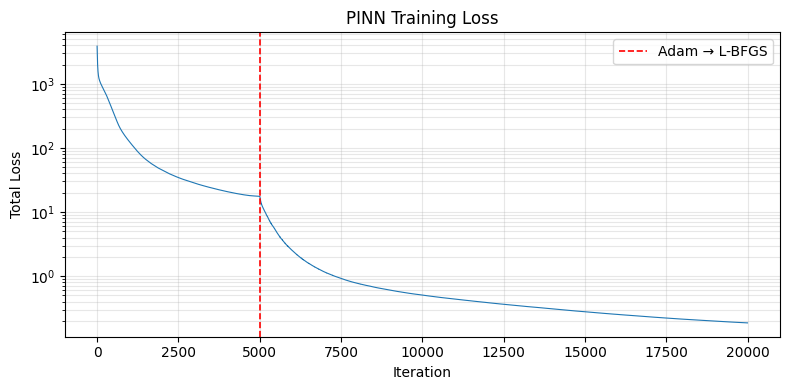

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(model.loss_history, linewidth=0.8)
ax.axvline(5000, color='red', linestyle='--', linewidth=1.2, label='Adam → L-BFGS')
ax.set_xlabel('Iteration')
ax.set_ylabel('Total Loss')
ax.set_title('PINN Training Loss')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('pinn_loss_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Solution fields  
Same 4-panel layout used in the POD-Galerkin notebook: $u_x$, $u_y$, $|\mathbf{u}|$, $p$.


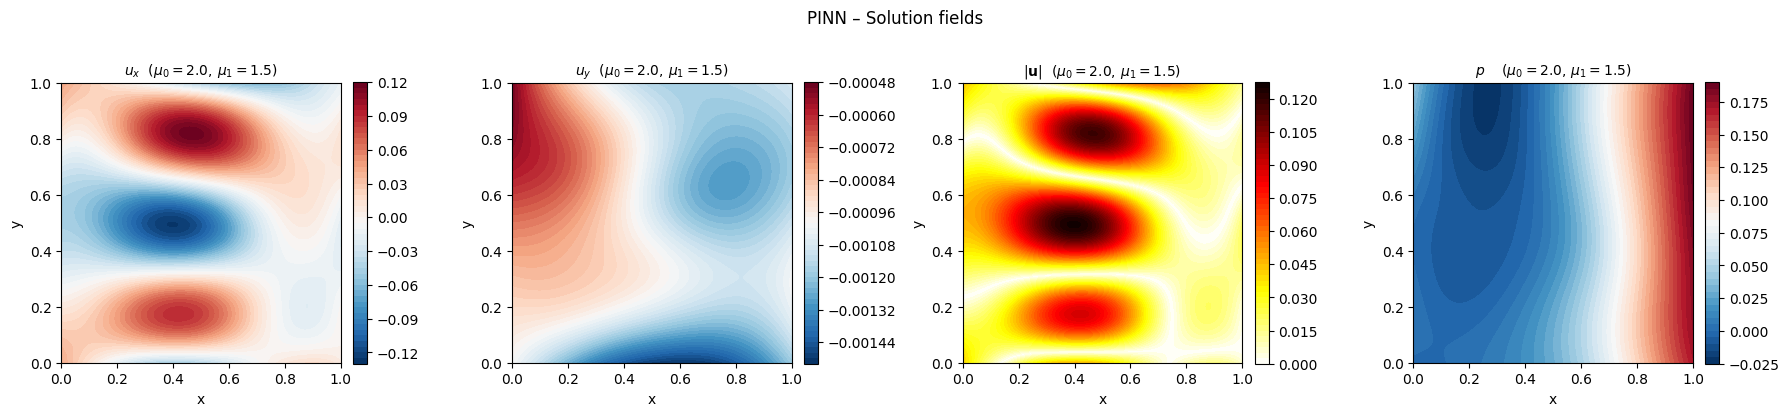

In [14]:
def plot_pinn_solution(model, mu0_val, mu1_val, N=200, save_path=None):
    
    x_lin = np.linspace(0, 1, N)
    y_lin = np.linspace(0, 1, N)
    XX, YY = np.meshgrid(x_lin, y_lin)
    x_flat = XX.ravel()[:, None].astype(np.float32)
    y_flat = YY.ravel()[:, None].astype(np.float32)

    ux, uy, p = model.predict(x_flat, y_flat, mu0_val, mu1_val)
    UX = ux.reshape(N, N)
    UY = uy.reshape(N, N)
    P  = p.reshape(N, N)
    UM = np.sqrt(UX**2 + UY**2)

    fields = [UX, UY, UM, P]
    titles = [f'$u_x$  ($\mu_0={mu0_val},\, \mu_1={mu1_val}$)',
              f'$u_y$  ($\mu_0={mu0_val},\, \mu_1={mu1_val}$)',
              f'$|\mathbf{{u}}|$  ($\mu_0={mu0_val},\, \mu_1={mu1_val}$)',
              f'$p$    ($\mu_0={mu0_val},\, \mu_1={mu1_val}$)']
    cmaps  = ['RdBu_r', 'RdBu_r', 'hot_r', 'RdBu_r']

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
        im = ax.contourf(XX, YY, field, levels=50, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('x');  ax.set_ylabel('y')
        ax.set_aspect('equal')
    plt.suptitle('PINN – Solution fields', fontsize=12, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return UX, UY, UM, P, XX, YY

# Plot for the same mu used in the POD-Galerkin notebook
UX, UY, UM, P, XX, YY = plot_pinn_solution(model, mu0_val=2.0, mu1_val=1.5,
                                             save_path='pinn_solution_fields.png')


## 8 · PDE residuals over the test set

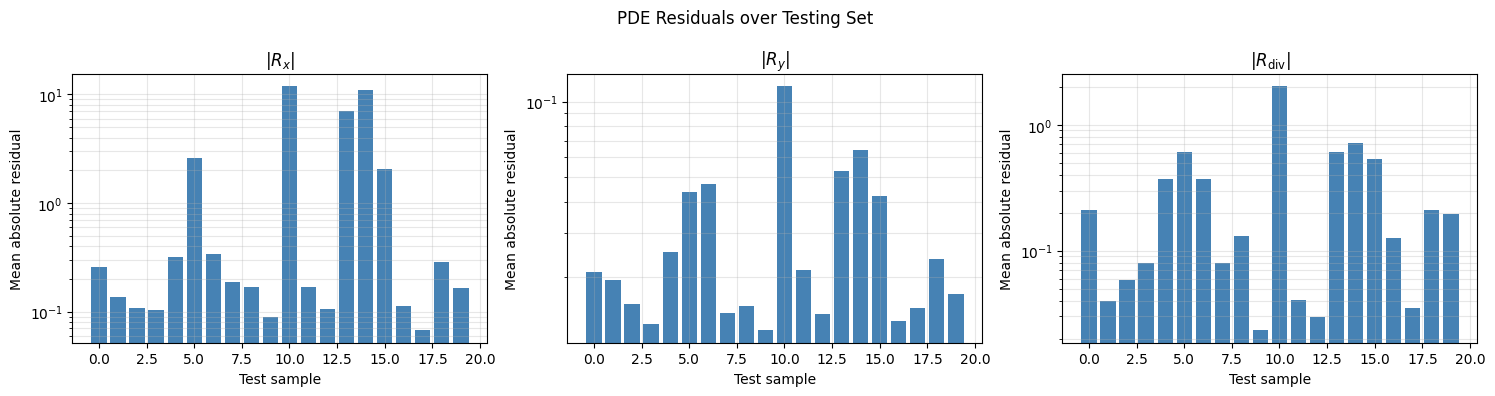

Mean |R_x|   = 1.859e+00   (max 1.203e+01)
Mean |R_y|   = 3.038e-02   (max 1.155e-01)
Mean |R_div| = 3.247e-01   (max 2.039e+00)


In [15]:
def evaluate_residuals(model, mu_test_list, N_pts=2000):
    """Mean absolute PDE residuals for each test parameter pair."""
    res_x_list, res_y_list, res_div_list = [], [], []

    for mu0_v, mu1_v in mu_test_list:
        # Random interior points
        xy = np.random.default_rng(99).uniform(0, 1, (N_pts, 2)).astype(np.float32)
        x_t   = torch.tensor(xy[:, 0:1]).to(device).requires_grad_(True)
        y_t   = torch.tensor(xy[:, 1:2]).to(device).requires_grad_(True)
        mu0_t = torch.full((N_pts, 1), mu0_v, dtype=torch.float32).to(device)
        mu1_t = torch.full((N_pts, 1), mu1_v, dtype=torch.float32).to(device)

        R_x, R_y, R_div = model.net_residual(x_t, y_t, mu0_t, mu1_t)
        res_x_list.append(R_x.abs().mean().item())
        res_y_list.append(R_y.abs().mean().item())
        res_div_list.append(R_div.abs().mean().item())

    return np.array(res_x_list), np.array(res_y_list), np.array(res_div_list)

# 20 random test parameters
np.random.seed(42)
mu_test = np.column_stack([
    np.random.uniform(0.1, 10.0, 20),
    np.random.uniform(1.0,  3.0, 20)
])

res_x, res_y, res_div = evaluate_residuals(model, mu_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, lbl in zip(axes,
                         [res_x, res_y, res_div],
                         ['$|R_x|$', '$|R_y|$', '$|R_{\mathrm{div}}|$']):
    ax.bar(range(len(vals)), vals, color='steelblue')
    ax.set_yscale('log')
    ax.set_xlabel('Test sample')
    ax.set_ylabel('Mean absolute residual')
    ax.set_title(lbl)
    ax.grid(True, which='both', alpha=0.3)
plt.suptitle('PDE Residuals over Testing Set', fontsize=12)
plt.tight_layout()
plt.savefig('pinn_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean |R_x|   = {res_x.mean():.3e}   (max {res_x.max():.3e})")
print(f"Mean |R_y|   = {res_y.mean():.3e}   (max {res_y.max():.3e})")
print(f"Mean |R_div| = {res_div.mean():.3e}   (max {res_div.max():.3e})")


## 9 · Parametric study  — velocity magnitude for varying $(\mu_0, \mu_1)$

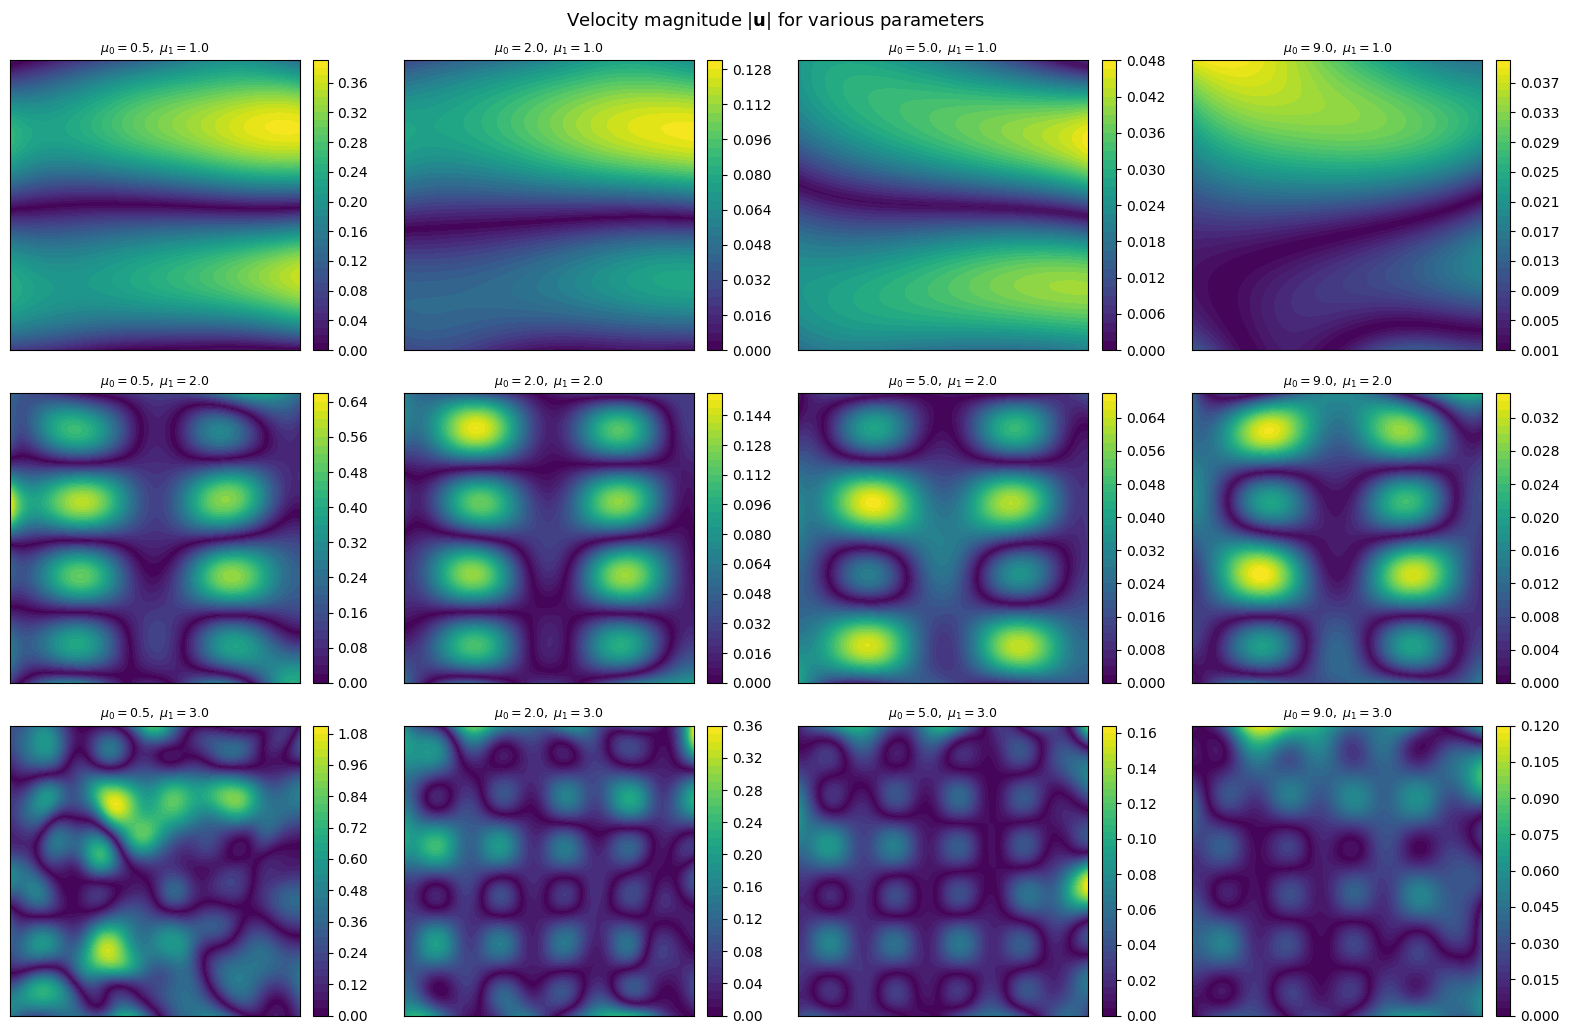

In [16]:
mu0_vals = [0.5, 2.0, 5.0, 9.0]
mu1_vals = [1.0, 2.0, 3.0]
N = 150

fig, axes = plt.subplots(len(mu1_vals), len(mu0_vals),
                         figsize=(4*len(mu0_vals), 3.5*len(mu1_vals)))

x_lin = np.linspace(0, 1, N)
y_lin = np.linspace(0, 1, N)
XX, YY = np.meshgrid(x_lin, y_lin)
x_flat = XX.ravel()[:, None].astype(np.float32)
y_flat = YY.ravel()[:, None].astype(np.float32)

for i, mu1_v in enumerate(mu1_vals):
    for j, mu0_v in enumerate(mu0_vals):
        ux, uy, _ = model.predict(x_flat, y_flat, mu0_v, mu1_v)
        um = np.sqrt(ux**2 + uy**2).reshape(N, N)
        im = axes[i, j].contourf(XX, YY, um, levels=40, cmap='viridis')
        plt.colorbar(im, ax=axes[i, j], fraction=0.046, pad=0.04)
        axes[i, j].set_title(f'$\mu_0={mu0_v},\;\mu_1={mu1_v}$', fontsize=9)
        axes[i, j].set_aspect('equal')
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])

plt.suptitle('Velocity magnitude $|\mathbf{u}|$ for various parameters', fontsize=13)
plt.tight_layout()
plt.savefig('pinn_parametric_study.png', dpi=150, bbox_inches='tight')
plt.show()


## 10 · Comparison with the High-Fidelity (FOM) solution



Relative L2 error  u_x : 1.8632e+00
Relative L2 error  u_y : 9.9291e-01
Relative L2 error  |u| : 1.2477e+00
Relative L2 error  p   : 9.8344e-01


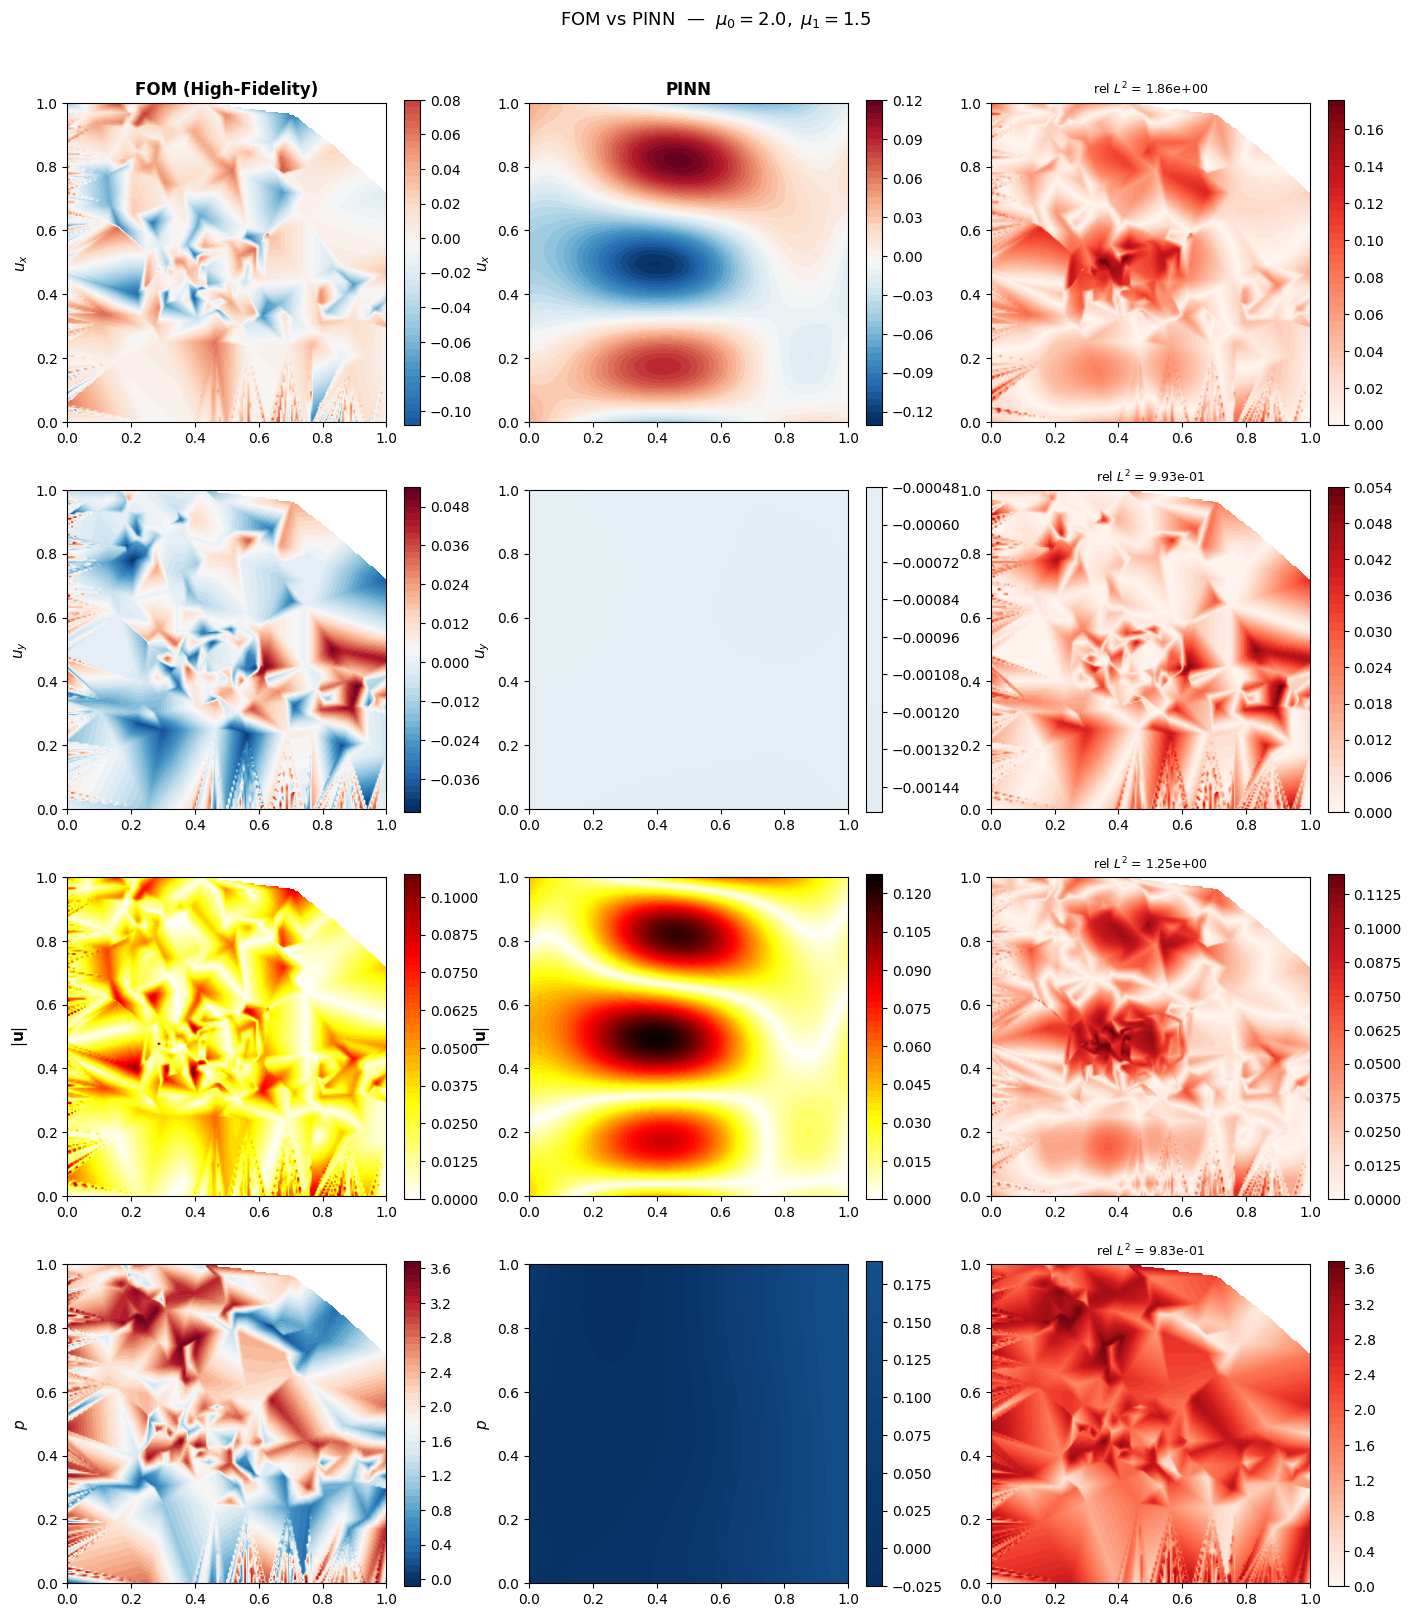

In [17]:
import os

MU0_TEST, MU1_TEST = 2.0, 1.5
N_GRID = 200

# ── Load FOM data ──────────────────────────────────────────────────────────
if not all(os.path.exists(f) for f in
           ['fom_coords.npy','fom_ux.npy','fom_uy.npy','fom_p.npy']):
    print("FOM data not found. Run the saving block in the POD-Galerkin notebook first.")
else:
    fom_coords = np.load('fom_coords.npy')
    fom_ux_raw = np.load('fom_ux.npy')
    fom_uy_raw = np.load('fom_uy.npy')
    fom_p_raw  = np.load('fom_p.npy')

    # ── Interpolate FOM onto a regular grid (same as PINN output) ─────────
    x_lin = np.linspace(0, 1, N_GRID)
    y_lin = np.linspace(0, 1, N_GRID)
    XX, YY = np.meshgrid(x_lin, y_lin)

    fom_ux_g = griddata(fom_coords, fom_ux_raw, (XX, YY), method='linear')
    fom_uy_g = griddata(fom_coords, fom_uy_raw, (XX, YY), method='linear')
    fom_p_g  = griddata(fom_coords, fom_p_raw,  (XX, YY), method='linear')
    fom_um_g = np.sqrt(fom_ux_g**2 + fom_uy_g**2)

    # ── PINN prediction on the same grid ──────────────────────────────────
    x_flat = XX.ravel()[:, None].astype(np.float32)
    y_flat = YY.ravel()[:, None].astype(np.float32)
    ux_p, uy_p, p_p = model.predict(x_flat, y_flat, MU0_TEST, MU1_TEST)
    ux_p = ux_p.reshape(N_GRID, N_GRID)
    uy_p = uy_p.reshape(N_GRID, N_GRID)
    p_p  = p_p.reshape(N_GRID, N_GRID)
    um_p = np.sqrt(ux_p**2 + uy_p**2)

    # ── Relative L2 error ─────────────────────────────────────────────────
    def rel_l2(pinn_f, fom_f):
        mask = ~np.isnan(fom_f)
        num  = np.linalg.norm(pinn_f[mask] - fom_f[mask])
        den  = np.linalg.norm(fom_f[mask])
        return num / den if den > 0 else np.nan

    err_ux = rel_l2(ux_p, fom_ux_g)
    err_uy = rel_l2(uy_p, fom_uy_g)
    err_p  = rel_l2(p_p,  fom_p_g)
    err_um = rel_l2(um_p, fom_um_g)

    print(f"Relative L2 error  u_x : {err_ux:.4e}")
    print(f"Relative L2 error  u_y : {err_uy:.4e}")
    print(f"Relative L2 error  |u| : {err_um:.4e}")
    print(f"Relative L2 error  p   : {err_p:.4e}")

    # ── Side-by-side comparison plots (FOM | PINN | |error|) ──────────────
    field_pairs = [
        ('$u_x$',           fom_ux_g, ux_p, err_ux, 'RdBu_r'),
        ('$u_y$',           fom_uy_g, uy_p, err_uy, 'RdBu_r'),
        ('$|\mathbf{u}|$', fom_um_g, um_p, err_um, 'hot_r'),
        ('$p$',             fom_p_g,  p_p,  err_p,  'RdBu_r'),
    ]

    fig, axes = plt.subplots(4, 3, figsize=(14, 16))
    col_titles = ['FOM (High-Fidelity)', 'PINN', 'Pointwise $|$error$|$']
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=12, fontweight='bold')

    for row, (label, fom_f, pinn_f, err, cmap) in enumerate(field_pairs):
        vmin = min(np.nanmin(fom_f), np.nanmin(pinn_f))
        vmax = max(np.nanmax(fom_f), np.nanmax(pinn_f))
        for col, field in enumerate([fom_f, pinn_f]):
            im = axes[row, col].contourf(XX, YY, field, levels=50,
                                         cmap=cmap, vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=axes[row, col], fraction=0.046)
            axes[row, col].set_ylabel(label, fontsize=11)
            axes[row, col].set_aspect('equal')

        diff = np.abs(pinn_f - fom_f)
        im = axes[row, 2].contourf(XX, YY, diff, levels=50, cmap='Reds')
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046)
        axes[row, 2].set_title(f'rel $L^2$ = {err:.2e}', fontsize=9)
        axes[row, 2].set_aspect('equal')

    plt.suptitle(f'FOM vs PINN  —  $\mu_0={MU0_TEST},\;\mu_1={MU1_TEST}$',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('pinn_vs_fom_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


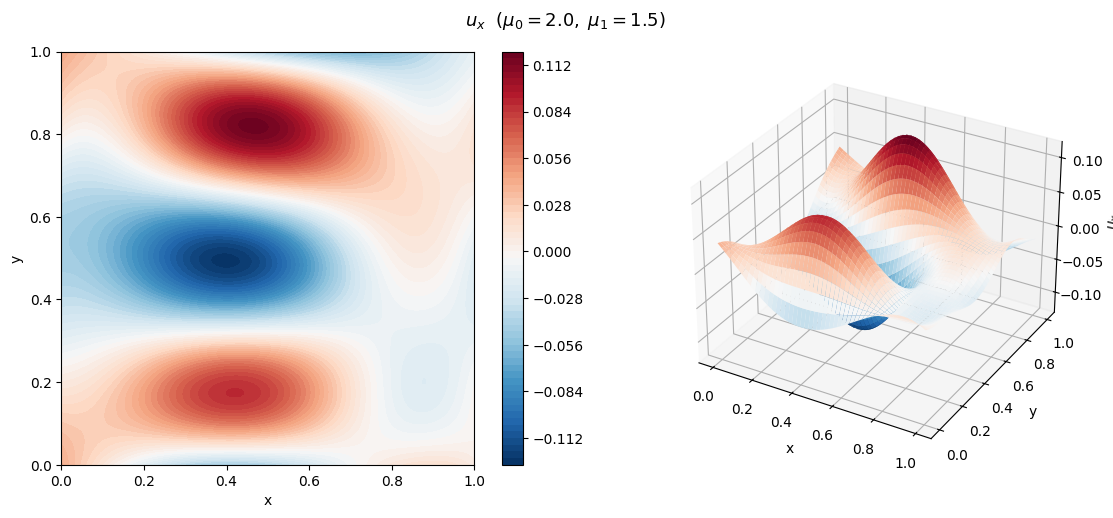

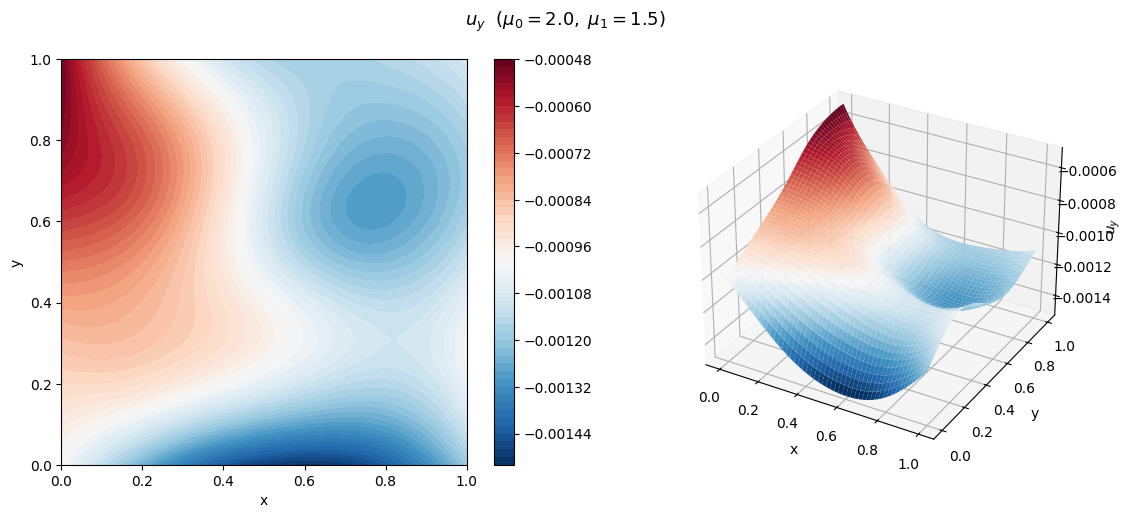

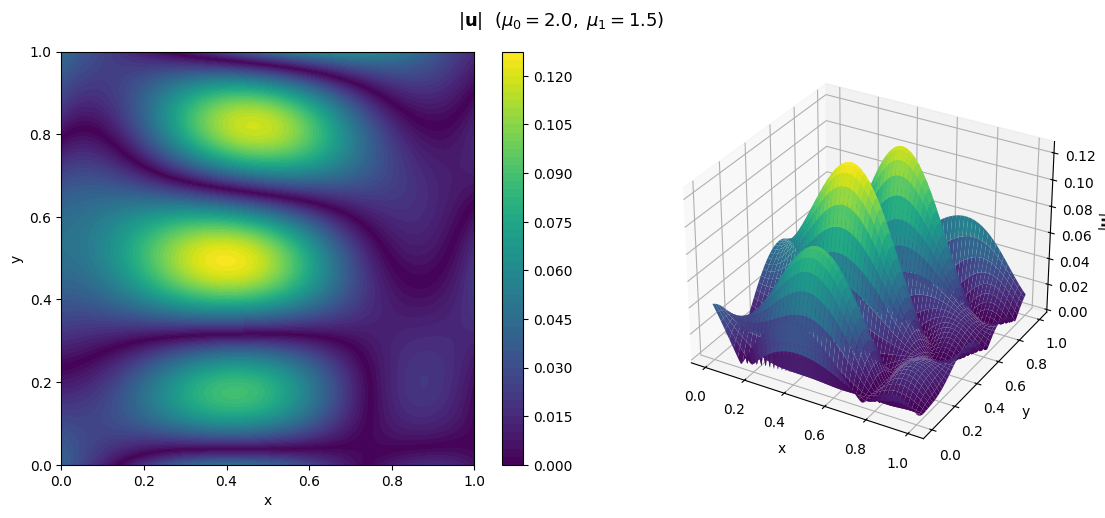

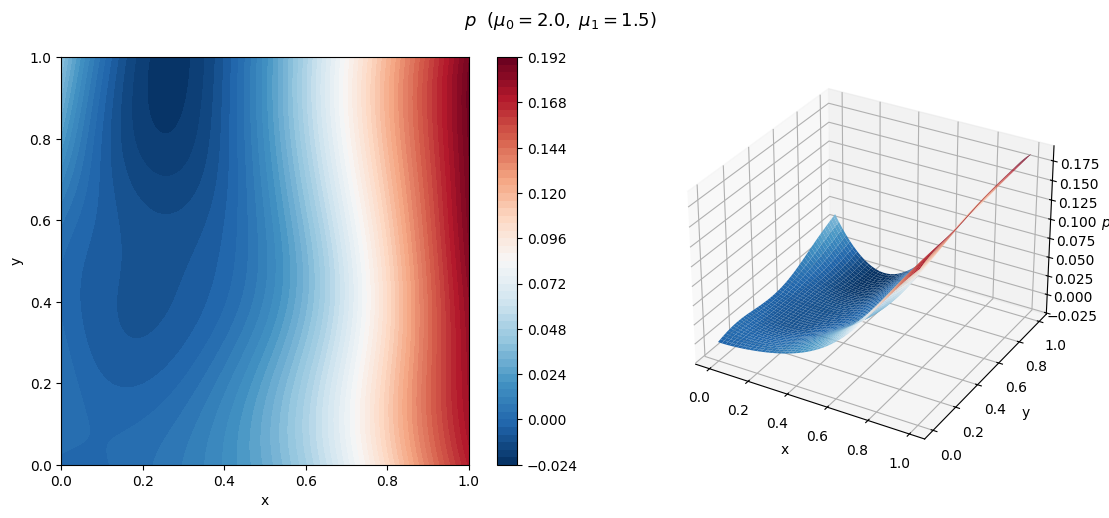

In [18]:
def plot_solution_pinn(model, mu0_val, mu1_val, field='u_x', N=200, save_path=None):
    """
    Replicates other_ut.plot_solution style:
      left  → 2D top-view colored field
      right → 3D surface plot
    field: 'u_x', 'u_y', 'u_mag', 'p'
    """
    x_lin = np.linspace(0, 1, N)
    y_lin = np.linspace(0, 1, N)
    XX, YY = np.meshgrid(x_lin, y_lin)
    x_flat = XX.ravel()[:, None].astype(np.float32)
    y_flat = YY.ravel()[:, None].astype(np.float32)

    ux, uy, p = model.predict(x_flat, y_flat, mu0_val, mu1_val)
    UX = ux.reshape(N, N)
    UY = uy.reshape(N, N)
    P  = p.reshape(N, N)
    UM = np.sqrt(UX**2 + UY**2)

    field_map = {'u_x': (UX, '$u_x$', 'RdBu_r'),
                 'u_y': (UY, '$u_y$', 'RdBu_r'),
                 'u_mag': (UM, '$|\\mathbf{u}|$', 'viridis'),
                 'p':   (P,  '$p$',   'RdBu_r')}
    Z, title, cmap = field_map[field]

    fig = plt.figure(figsize=(12, 5))
    fig.suptitle(f'{title}  ($\\mu_0={mu0_val},\\;\\mu_1={mu1_val}$)', fontsize=13)

    # --- Left: 2D top-view ---------------------------------------------------
    ax2d = fig.add_subplot(1, 2, 1)
    im = ax2d.contourf(XX, YY, Z, levels=60, cmap=cmap)
    plt.colorbar(im, ax=ax2d)
    ax2d.set_xlabel('x');  ax2d.set_ylabel('y')
    ax2d.set_aspect('equal')

    # --- Right: 3D surface ---------------------------------------------------
    ax3d = fig.add_subplot(1, 2, 2, projection='3d')
    ax3d.plot_surface(XX, YY, Z, cmap=cmap, linewidth=0, antialiased=True,
                      rstride=4, cstride=4)
    ax3d.set_xlabel('x');  ax3d.set_ylabel('y');  ax3d.set_zlabel(title)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# --- Plot all four fields ---
for f in ['u_x', 'u_y', 'u_mag', 'p']:
    plot_solution_pinn(model, mu0_val=2.0, mu1_val=1.5, field=f,
                       save_path=f'pinn_{f}.png')